In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [92]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [93]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [95]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [96]:
df = df.dropna()

In [107]:
from sklearn.preprocessing import StandardScaler

# Select features and target
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
        'total_bedrooms', 'population', 'households', 'median_income']]
y = df[['median_house_value']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [106]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Use scaled features
model = LinearRegression()

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X_scaled, y.values.ravel(), cv=5, scoring='neg_mean_absolute_error')

# Report average score
print("Mean MAE (5-fold CV):", -cv_scores.mean())


Mean MAE (5-fold CV): 52797.90986469564


In [108]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20)


In [113]:
X.shape

(20433, 8)

In [115]:
y.shape

(20433, 1)

In [116]:
preds.shape

(4087, 1)

In [157]:
!pip install xgboost


In [149]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [150]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=42)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [151]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost MAE:", mae)
print("XGBoost MSE:", mse)
print("XGBoost R²:", r2)


XGBoost MAE: 31168.508969942806
XGBoost MSE: 2218301278.15533
XGBoost R²: 0.8306812172355418


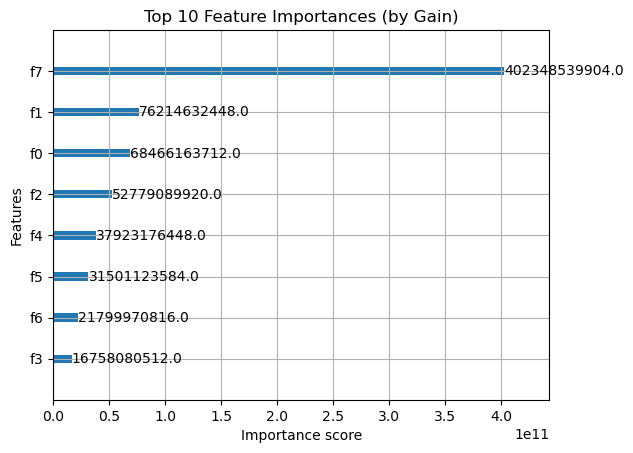

In [152]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances (by Gain)")
plt.show()


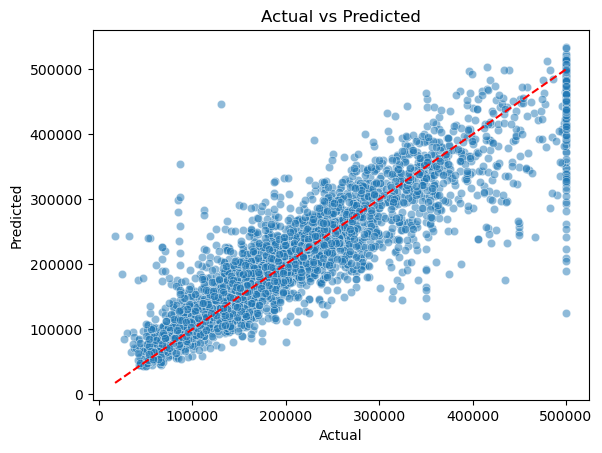

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 1D
y_test_1d = y_test.values.ravel()
y_pred_1d = y_pred.ravel()

sns.scatterplot(x=y_test_1d, y=y_pred_1d, alpha=0.5)
plt.plot([y_test_1d.min(), y_test_1d.max()], [y_test_1d.min(), y_test_1d.max()], '--r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


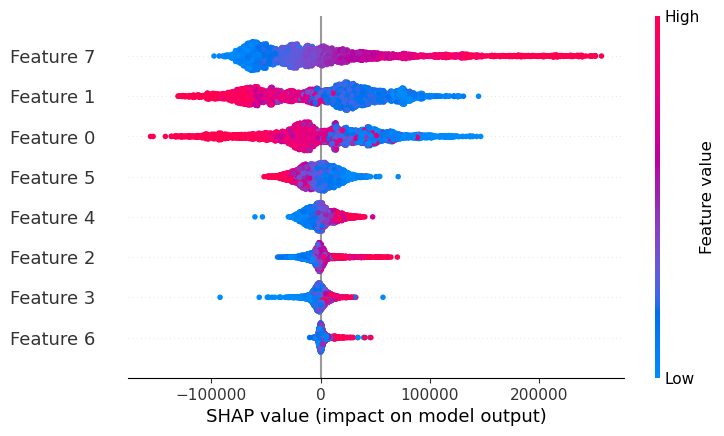

In [154]:
!pip install shap
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)


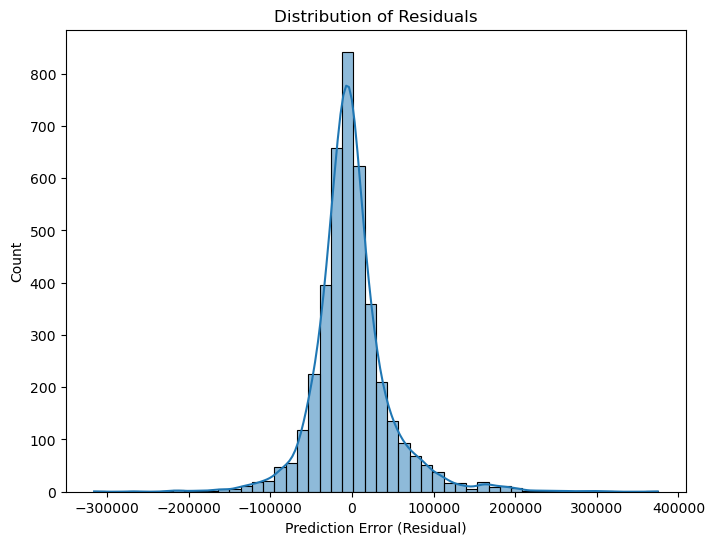

In [155]:
y_test_1d = y_test.values.ravel()
y_pred_1d = y_pred.ravel()
residuals = y_test_1d - y_pred_1d

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Prediction Error (Residual)")
plt.title("Distribution of Residuals")
plt.show()


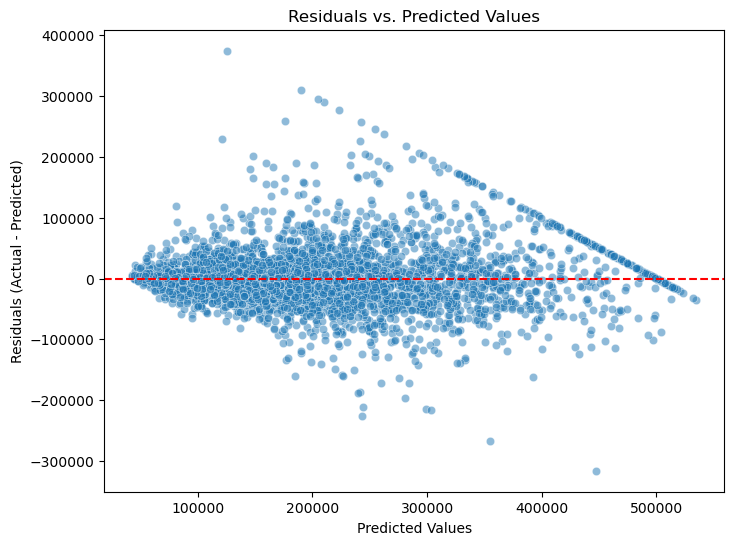

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 1D format
y_test_flat = y_test.squeeze()  # or y_test.squeeze()
y_pred_flat = y_pred.squeeze()

# Compute residuals
residuals = y_test_flat - y_pred_flat

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_flat, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.show()


In [158]:
pip freeze > requirements.txt


Note: you may need to restart the kernel to use updated packages.
